# Bank Marketing Campaign — Customer Targeting Analysis

**Aim:** Figure out which customer profiles are most likely to subscribe to a term
deposit, and which contact strategies actually work — so a bank can target its
calling campaign more efficiently instead of calling everyone.

**Dataset:** UCI Bank Marketing dataset — real telemarketing campaign data from a
Portuguese bank (41,188 rows, 21 columns). Genuinely real data, not synthetic.

**Sections:**
1. Setup & Data Audit
2. Cleaning Decisions (handling 'unknown' values, duplicates)
3. (more sections added as we go)


## 1. Setup & Data Audit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Note: this file uses ';' as separator, not ',' -- check this yourself if you
# ever load a new dataset and get a single garbled column back
df = pd.read_csv('bank-additional-full.csv', sep=';')
print("Shape:", df.shape)
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [3]:
# Standard null check -- but this dataset hides missingness differently, see next cell
print("Standard nulls per column:")
print(df.isnull().sum())

Standard nulls per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


**Important real-data quirk:** this dataset has **zero technical NaN values**, but
several columns use the literal string `"unknown"` to represent missing/unrecorded
information. A plain `.isnull().sum()` would miss this completely -- worth remembering
as a lesson: always check *categorical value counts*, not just `.isnull()`, especially
on real-world data.

In [4]:
# Check every categorical column for 'unknown' as a disguised missing value
cat_cols = df.select_dtypes(include='object').columns
for c in cat_cols:
    n_unknown = (df[c] == 'unknown').sum()
    if n_unknown > 0:
        pct = n_unknown / len(df) * 100
        print(f"{c}: {n_unknown} unknowns ({pct:.1f}%)")

job: 330 unknowns (0.8%)
marital: 80 unknowns (0.2%)
education: 1731 unknowns (4.2%)
default: 8597 unknowns (20.9%)
housing: 990 unknowns (2.4%)
loan: 990 unknowns (2.4%)


/tmp/ipykernel_479/817884078.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [5]:
# Duplicate check
print("Full duplicate rows:", df.duplicated().sum())

Full duplicate rows: 12


y
no     36548
yes     4640
Name: count, dtype: int64
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


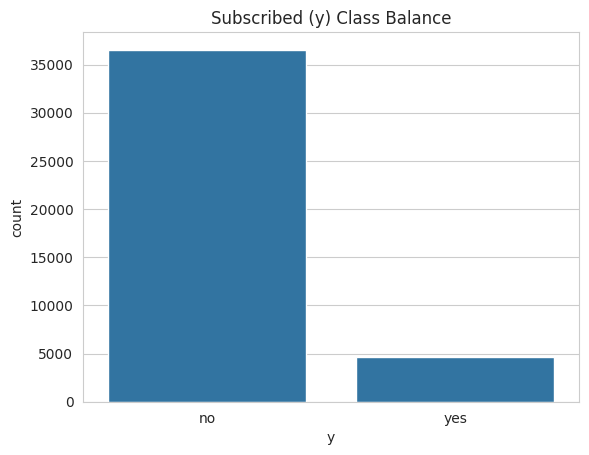

In [6]:
# Target variable balance
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True) * 100)

sns.countplot(x='y', data=df)
plt.title('Subscribed (y) Class Balance')
plt.show()

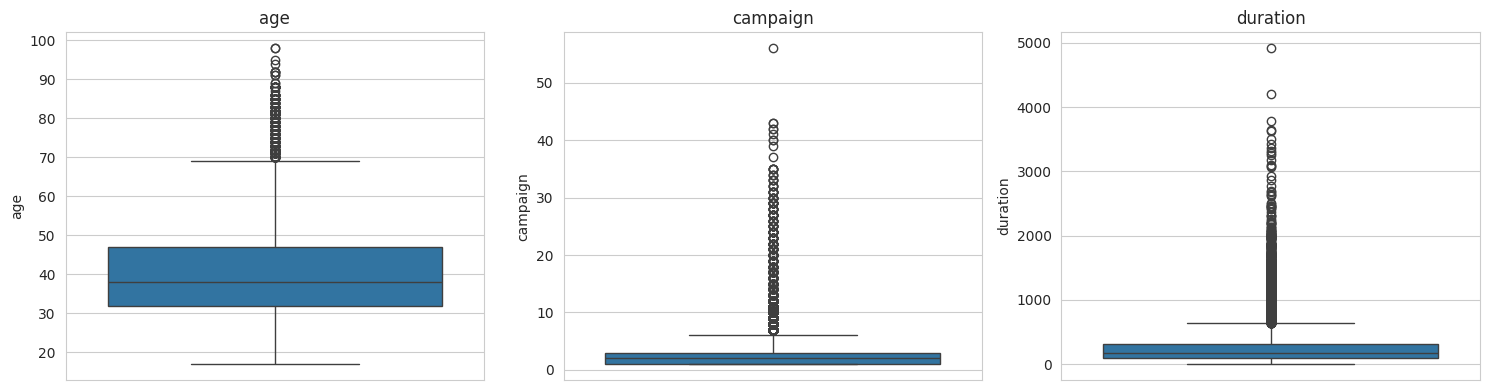

In [7]:
# Basic outlier scan on key numeric columns
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['age', 'campaign', 'duration']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Audit notes -- fill these in yourself after running the cells above:**
- Which columns have the most "unknown" values, and does that make sense given what
  the column represents (e.g. is `default` a sensitive question people might not answer)?
- Does `campaign` (number of contacts) have extreme outliers? What might explain them?
- Is `duration` (call length in seconds) something that makes sense to know *before*
  making a call, or only *after*? (Hint: this matters a lot for how you use this column later.)
- How imbalanced is `y`? What could that mean if we eventually build a prediction model?


## 2. Cleaning Decisions

We found earlier that several columns use `"unknown"` instead of a real value.
For each one, we have three real options:
- **Drop rows** with unknown (risky if it removes a lot of data or removes a
  meaningful pattern -- e.g. if people who don't answer 'default' behave differently)
- **Keep 'unknown' as its own category** (often the safest choice -- it might
  itself be a meaningful signal, e.g. people cagey about default history may
  behave differently than people who answer)
- **Impute** with the most common value (risky -- can hide a real pattern)

We will keep 'unknown' as its own valid category rather than dropping or imputing,
because dropping would lose ~21% of rows just from the `default` column alone, and
'unknown' may itself carry signal worth analyzing later.

In [8]:
# Check how much data we would LOSE if we dropped all unknown rows -- this justifies our decision
cols_with_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']
rows_before = len(df)
rows_if_dropped = len(df[~(df[cols_with_unknown] == 'unknown').any(axis=1)])
print(f"Rows before: {rows_before}")
print(f"Rows if we dropped any row with an unknown: {rows_if_dropped}")
print(f"Rows lost: {rows_before - rows_if_dropped} ({(rows_before - rows_if_dropped)/rows_before*100:.1f}%)")

Rows before: 41188
Rows if we dropped any row with an unknown: 30488
Rows lost: 10700 (26.0%)


In [9]:
# Drop exact duplicate rows -- these are true row-for-row repeats, safe to remove
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Dropped {before - after} duplicate rows. New shape: {df.shape}")

Dropped 12 duplicate rows. New shape: (41176, 21)


In [10]:
# Quick check: does the 'unknown' default rate differ from the overall 'no' rate?
# This is a real test of whether 'unknown' carries a pattern worth keeping as its own category
default_unknown_subscribe_rate = df[df['default']=='unknown']['y'].value_counts(normalize=True)
overall_subscribe_rate = df['y'].value_counts(normalize=True)

print('Subscribe rate when default status is unknown:')
print(default_unknown_subscribe_rate * 100)
print()
print('Overall subscribe rate:')
print(overall_subscribe_rate * 100)

Subscribe rate when default status is unknown:
y
no     94.84644
yes     5.15356
Name: proportion, dtype: float64

Overall subscribe rate:
y
no     88.733728
yes    11.266272
Name: proportion, dtype: float64


**Extending the check to all 6 affected columns, not just `default`**

Testing only one column and generalizing to the rest would be weak reasoning -- each
column could behave differently. Let's check subscribe rate for 'unknown' vs. the
overall average, across every column that has unknowns.

In [11]:
cols_with_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']
overall_rate = (df['y']=='yes').mean()*100

print(f"Overall subscribe rate: {overall_rate:.2f}%")
print()

for c in cols_with_unknown:
    unknown_rate = (df[df[c]=='unknown']['y']=='yes').mean()*100
    n_unknown = (df[c]=='unknown').sum()
    if n_unknown > 0:
        diff = unknown_rate - overall_rate
        print(f"{c:12s}: {n_unknown:5d} unknowns -> subscribe rate {unknown_rate:5.2f}%  (diff from avg: {diff:+.2f}pp)")

Overall subscribe rate: 11.27%

job         :   330 unknowns -> subscribe rate 11.21%  (diff from avg: -0.05pp)
marital     :    80 unknowns -> subscribe rate 15.00%  (diff from avg: +3.73pp)
education   :  1730 unknowns -> subscribe rate 14.51%  (diff from avg: +3.24pp)
default     :  8596 unknowns -> subscribe rate  5.15%  (diff from avg: -6.11pp)
housing     :   990 unknowns -> subscribe rate 10.81%  (diff from avg: -0.46pp)
loan        :   990 unknowns -> subscribe rate 10.81%  (diff from avg: -0.46pp)


**Interpretation prompt (fill in yourself after running the cell above):**
Compare the two subscribe rates -- are they similar, or does the 'unknown' group behave
noticeably differently? If they differ meaningfully, that's your justification for keeping
'unknown' as a real category instead of dropping/imputing it away.

**Refined decision -- treat each column based on its own evidence, not a blanket rule**

Looking at the per-column comparison above:
- `default`: -6.11pp difference -> strong signal -> **keep 'unknown' as its own category**
- `education`: +3.23pp, `marital`: +3.73pp -> mild but real signal -> **keep as their own category**
- `job`: -0.05pp, `housing`: -0.46pp, `loan`: -0.46pp -> negligible, close to random noise
  -> since 'unknown' carries no real information here, it's safe to **drop these specific rows**
  rather than keep a category that adds noise without insight

This is a more defensible position than applying the same treatment to all 6 columns --
each decision is backed by its own evidence.

In [12]:
# Drop rows where job, housing, or loan are 'unknown' -- these showed negligible
# difference from the overall average, so 'unknown' isn't hiding useful signal here.
# We keep 'unknown' as-is in default, education, and marital, since those showed real effects.

before = len(df)
df = df[(df['job'] != 'unknown') & (df['housing'] != 'unknown') & (df['loan'] != 'unknown')]
after = len(df)
print(f"Dropped {before - after} rows ({(before-after)/before*100:.2f}% of data)")
print(f"New shape: {df.shape}")

Dropped 1315 rows (3.19% of data)
New shape: (39861, 21)


## 3. Segmentation

Now we group customers by profile characteristics and check the subscribe rate
('y' = yes) for each group. Remember our baseline: **~11.3% subscribe overall**.
Any group meaningfully above that is a good target; any group meaningfully below
is a group to deprioritize.

We will look at four profile dimensions one at a time: job, education, age band,
and existing loans (housing/personal).

job
student          30.99
retired          25.33
unemployed       14.49
admin.           12.97
management       11.36
technician       10.76
self-employed    10.64
housemaid         9.99
entrepreneur      8.52
services          8.17
blue-collar       6.90
Name: y, dtype: float64


/tmp/ipykernel_479/3888351104.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_rate.values, y=job_rate.index, palette='viridis')


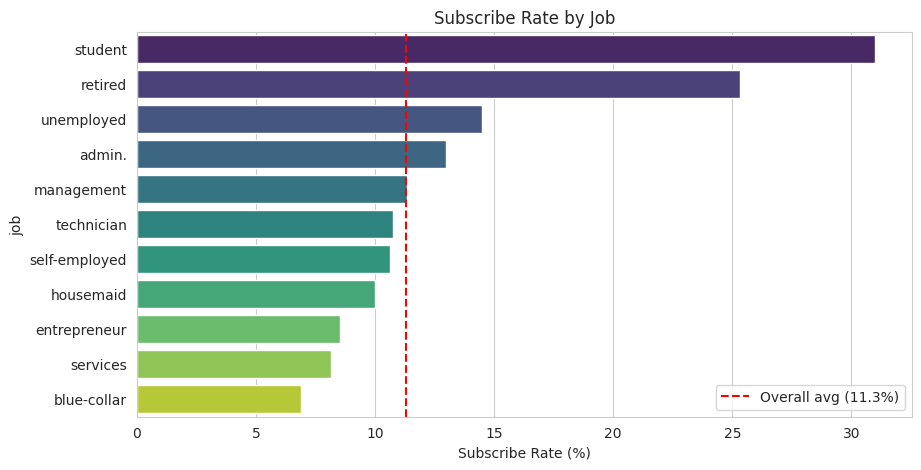

In [13]:
# Subscribe rate by job
job_rate = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=False)
print(job_rate.round(2))

plt.figure(figsize=(10,5))
sns.barplot(x=job_rate.values, y=job_rate.index, palette='viridis')
plt.xlabel('Subscribe Rate (%)')
plt.title('Subscribe Rate by Job')
plt.axvline(11.3, color='red', linestyle='--', label='Overall avg (11.3%)')
plt.legend()
plt.show()

education
illiterate             22.22
unknown                14.67
university.degree      13.71
professional.course    11.33
high.school            10.89
basic.4y               10.31
basic.6y                8.15
basic.9y                7.83
Name: y, dtype: float64


/tmp/ipykernel_479/1304217610.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_rate.values, y=edu_rate.index, palette='viridis')


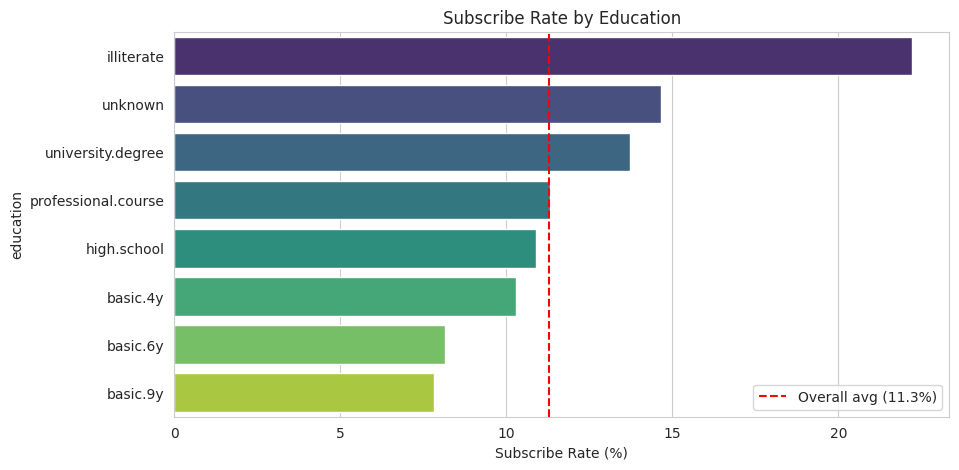

In [14]:
# Subscribe rate by education
edu_rate = df.groupby('education')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=False)
print(edu_rate.round(2))

plt.figure(figsize=(10,5))
sns.barplot(x=edu_rate.values, y=edu_rate.index, palette='viridis')
plt.xlabel('Subscribe Rate (%)')
plt.title('Subscribe Rate by Education')
plt.axvline(11.3, color='red', linestyle='--', label='Overall avg (11.3%)')
plt.legend()
plt.show()

marital
single      13.97
unknown     12.86
divorced    10.39
married     10.19
Name: y, dtype: float64


/tmp/ipykernel_479/3875455535.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=marital_rate.index, y=marital_rate.values, palette='viridis')


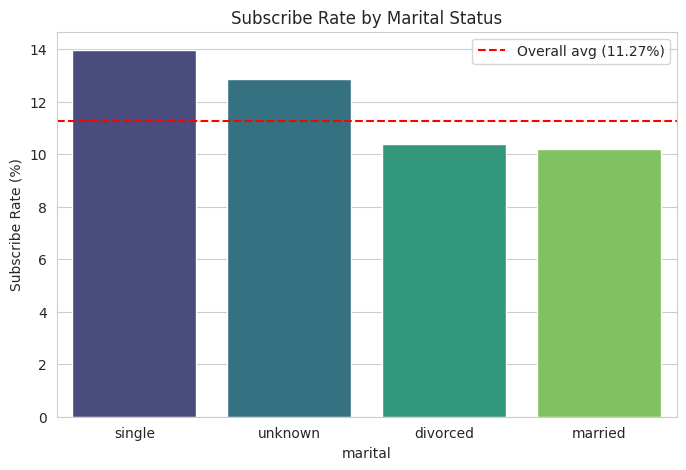

In [15]:
# Subscribe rate by marital status -- added after questioning why this column was skipped
marital_rate = df.groupby('marital')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=False)
print(marital_rate.round(2))

plt.figure(figsize=(8,5))
sns.barplot(x=marital_rate.index, y=marital_rate.values, palette='viridis')
plt.ylabel('Subscribe Rate (%)')
plt.title('Subscribe Rate by Marital Status')
plt.axhline(11.27, color='red', linestyle='--', label='Overall avg (11.27%)')
plt.legend()
plt.show()

age_band
18-30    15.15
31-40     9.82
41-50     8.17
51-60    10.68
60+      45.51
Name: y, dtype: float64


/tmp/ipykernel_479/3825850757.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_rate.index, y=age_rate.values, palette='viridis')


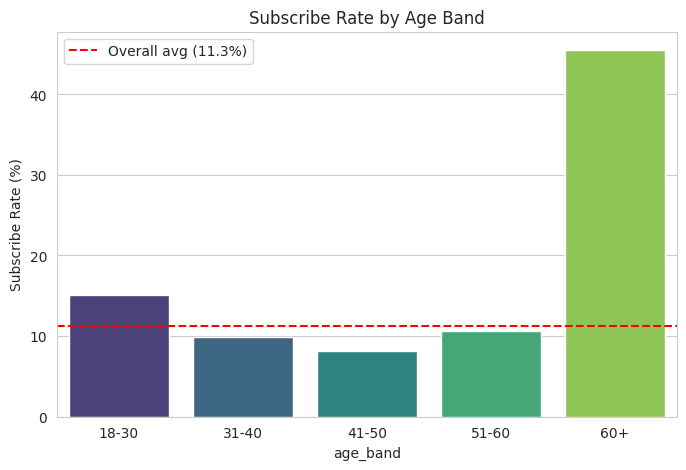

In [16]:
# Subscribe rate by age band -- we create bins first since age is continuous
df['age_band'] = pd.cut(df['age'], bins=[17,30,40,50,60,100],
                          labels=['18-30','31-40','41-50','51-60','60+'])

age_rate = df.groupby('age_band', observed=True)['y'].apply(lambda x: (x=='yes').mean()*100)
print(age_rate.round(2))

plt.figure(figsize=(8,5))
sns.barplot(x=age_rate.index, y=age_rate.values, palette='viridis')
plt.ylabel('Subscribe Rate (%)')
plt.title('Subscribe Rate by Age Band')
plt.axhline(11.3, color='red', linestyle='--', label='Overall avg (11.3%)')
plt.legend()
plt.show()

/tmp/ipykernel_479/628866918.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=housing_rate.index, y=housing_rate.values, ax=axes[0], palette='viridis')
/tmp/ipykernel_479/628866918.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loan_rate.index, y=loan_rate.values, ax=axes[1], palette='viridis')


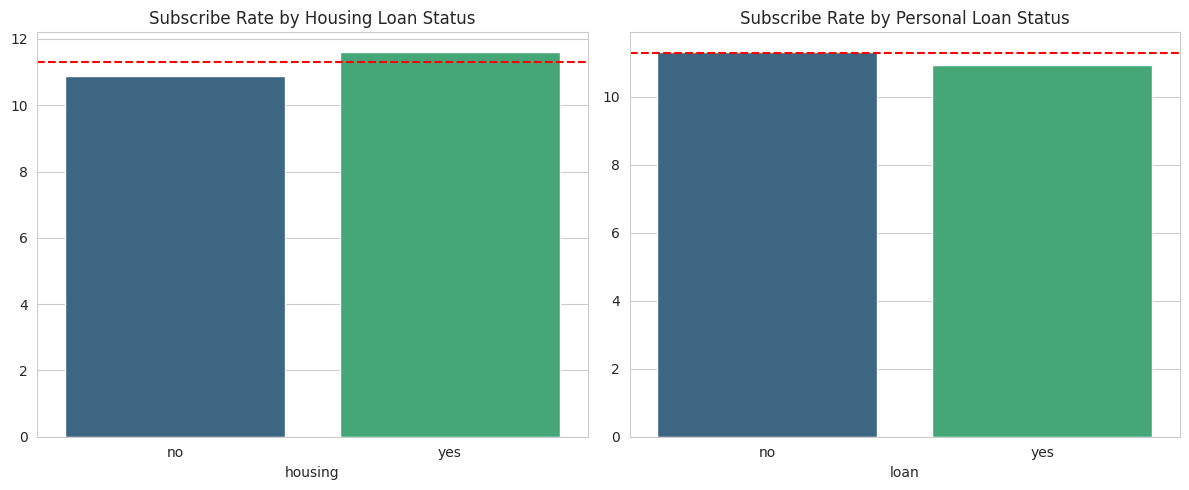

In [17]:
# Subscribe rate by existing loans -- housing loan and personal loan separately
housing_rate = df.groupby('housing')['y'].apply(lambda x: (x=='yes').mean()*100)
loan_rate = df.groupby('loan')['y'].apply(lambda x: (x=='yes').mean()*100)

fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.barplot(x=housing_rate.index, y=housing_rate.values, ax=axes[0], palette='viridis')
axes[0].set_title('Subscribe Rate by Housing Loan Status')
axes[0].axhline(11.3, color='red', linestyle='--')

sns.barplot(x=loan_rate.index, y=loan_rate.values, ax=axes[1], palette='viridis')
axes[1].set_title('Subscribe Rate by Personal Loan Status')
axes[1].axhline(11.3, color='red', linestyle='--')
plt.tight_layout()
plt.show()

**Fill in yourself after running the cells above:**
- Which job categories are clearly above the 11.3% average? Any surprises?
- Does higher education correlate with higher subscribe rate, or is it messier than that?
- Which age band stands out the most, above or below average?
- Do housing/personal loans seem to matter much, or is the difference small?

These answers become your raw material for Section 4, where we combine the strongest
signals into an actual targeting recommendation.

## 4. Combined Segment Analysis

Section 3 looked at single traits in isolation (job alone, age alone). But a real
targeting decision usually combines traits -- e.g. "retired AND single" might convert
even better than either trait alone. Here we combine our strongest single-factor
findings (age band + job) and check both the subscribe rate AND the group size for
each combination.

**Important caution:** a combination with a high subscribe rate but a tiny number of
people isn't a reliable target -- it could just be random chance. We check size
alongside rate for exactly this reason.

In [18]:
# Combine age_band and job, check subscribe rate AND group size together
combo = df.groupby(['age_band', 'job'], observed=True)['y'].agg(
    subscribe_rate=lambda x: (x=='yes').mean()*100,
    group_size='count'
).reset_index()

# Only look at combinations with a reasonably sized group (at least 100 people)
# -- this filters out tiny, unreliable combinations
reliable_combo = combo[combo['group_size'] >= 100].sort_values('subscribe_rate', ascending=False)
print(reliable_combo.head(15).to_string(index=False))

age_band           job  subscribe_rate  group_size
     60+       retired       46.212121         660
   18-30       student       32.865169         712
   31-40       student       21.374046         131
   18-30    unemployed       21.341463         164
   51-60    unemployed       17.482517         143
   18-30        admin.       17.141500        2106
   18-30 self-employed       15.354331         254
   18-30    management       15.057915         259
   51-60        admin.       14.383562        1168
   31-40    unemployed       13.486005         393
   18-30    technician       13.345040        1139
   51-60       retired       12.374582         897
   31-40    management       11.581921        1062
   31-40        admin.       11.311223        4553
   51-60    management       11.217949         624


**What to look for above:** which age+job combinations have both a high subscribe
rate AND a decent group size (100+ people)? Those are your genuinely reliable, actionable
targets -- not just the highest number in isolation.

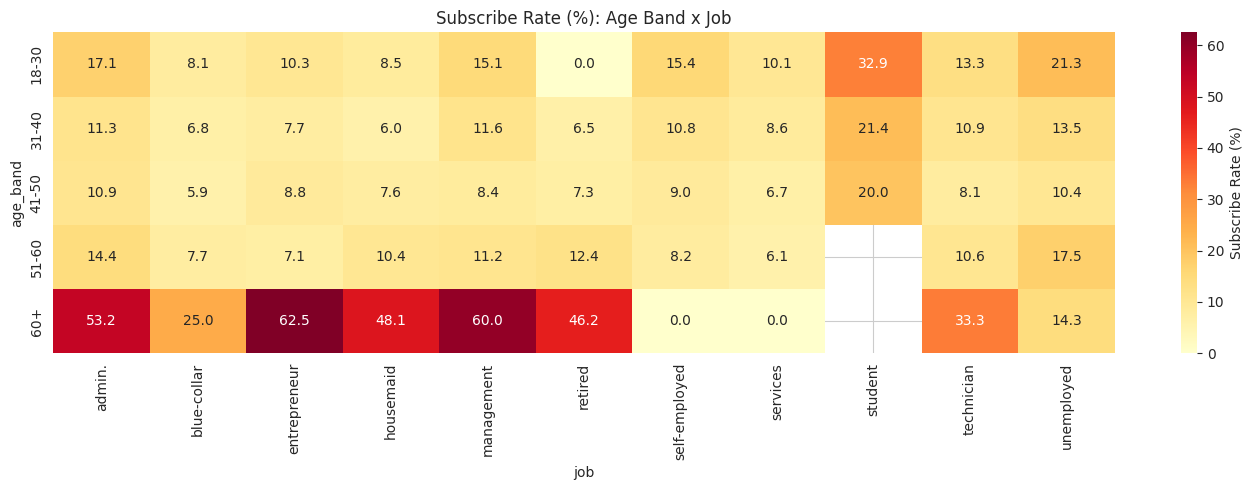

In [19]:
# Visualize as a heatmap for a clearer picture across all combinations (regardless of size, for now)
pivot = df.pivot_table(values='y', index='age_band', columns='job',
                         aggfunc=lambda x: (x=='yes').mean()*100, observed=True)

plt.figure(figsize=(14,5))
sns.heatmap(pivot.round(1), annot=True, cmap='YlOrRd', fmt='.1f', cbar_kws={'label':'Subscribe Rate (%)'})
plt.title('Subscribe Rate (%): Age Band x Job')
plt.tight_layout()
plt.show()

**Fill in yourself after running the cells above:**
- Which combined segment looks like the strongest, reliable target (high rate + decent size)?
- Are there any high-rate cells in the heatmap that you should be suspicious of because
  the group is probably small (e.g. student + 60+ age band is likely a tiny group)?
- Does this combined view change your earlier single-factor conclusions from Section 3,
  or mostly confirm them?

### 4b. Second combination: marital status x age band

Section 3 found two separate strong signals: **single** customers (14.0%) and
**60+** customers (45.5%). A natural question: are these actually the same people
overlapping (e.g. most 60+ customers are widowed/divorced, and "single" mostly
means young people), or two genuinely separate effects? Combining them tells us.

In [20]:
combo2 = df.groupby(['age_band', 'marital'], observed=True)['y'].agg(
    subscribe_rate=lambda x: (x=='yes').mean()*100,
    group_size='count'
).reset_index()

reliable_combo2 = combo2[combo2['group_size'] >= 100].sort_values('subscribe_rate', ascending=False)
print(reliable_combo2.head(10).to_string(index=False))

age_band  marital  subscribe_rate  group_size
     60+ divorced       46.551724         174
     60+  married       45.495495         666
   18-30   single       17.931483        4612
   31-40   single       11.604642        4998
   51-60  married       10.884801        4566
   51-60   single       10.510511         333
   18-30  married       10.254201        2321
   51-60 divorced        9.928444        1118
   41-50   single        9.127625        1238
   31-40 divorced        9.122085        1458


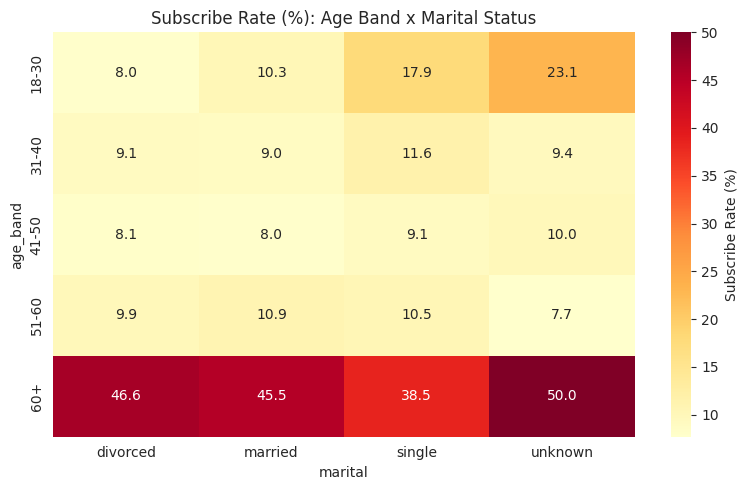

In [21]:
pivot2 = df.pivot_table(
    values='y',
    index='age_band',
    columns='marital',
    aggfunc=lambda x: (x=='yes').mean()*100,
    observed=True
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot2.round(1), annot=True, cmap='YlOrRd', fmt='.1f', cbar_kws={'label':'Subscribe Rate (%)'})
plt.title('Subscribe Rate (%): Age Band x Marital Status')
plt.tight_layout()
plt.show()

**Interpretation:** check whether the 60+ group is uniformly high across all marital
statuses (meaning age is the real driver, marital status incidental) or whether one
marital status within 60+ stands out much more than others (meaning the two factors
interact, not just add up independently).

## 5. Contact Strategy Analysis

Sections 3-4 answered "who to call." This section answers "how to call them" --
does the number of contact attempts matter, does timing (month) matter, does a
customer's response to a *previous* campaign predict this one, and a key trap
around the `duration` column.

          subscribe_rate  group_size
campaign                            
1                  12.98       17064
2                  11.51       10239
3                  10.82        5165
4                   9.56        2564
5                   7.56        1560
6                   7.68         951
7                   6.09         608
8                   4.15         386
9                   6.32         269
10                  4.65         215


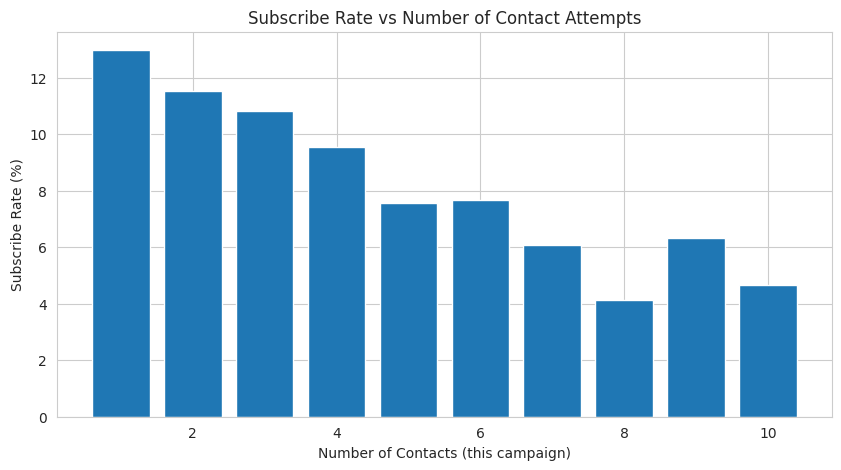

In [22]:
# Does number of contact attempts (during THIS campaign) relate to success?
campaign_rate = df.groupby('campaign')['y'].agg(
    subscribe_rate=lambda x: (x=='yes').mean()*100,
    group_size='count'
)
# Focus on 1-10 attempts -- beyond that, group sizes get very small and unreliable
campaign_rate_reliable = campaign_rate[campaign_rate['group_size'] >= 50].head(10)
print(campaign_rate_reliable.round(2))

plt.figure(figsize=(10,5))
plt.bar(campaign_rate_reliable.index, campaign_rate_reliable['subscribe_rate'])
plt.xlabel('Number of Contacts (this campaign)')
plt.ylabel('Subscribe Rate (%)')
plt.title('Subscribe Rate vs Number of Contact Attempts')
plt.show()

**What to look for:** does subscribe rate go up, down, or flatten out as contact
attempts increase? If it drops off after a certain point, that's evidence for a
"stop calling after N attempts" policy -- a concrete, actionable recommendation.

             subscribe_rate  group_size
poutcome                               
success               65.38        1326
failure               13.90        4123
nonexistent            8.88       34412


/tmp/ipykernel_479/2933702167.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=poutcome_rate.index, y=poutcome_rate['subscribe_rate'], palette='viridis')


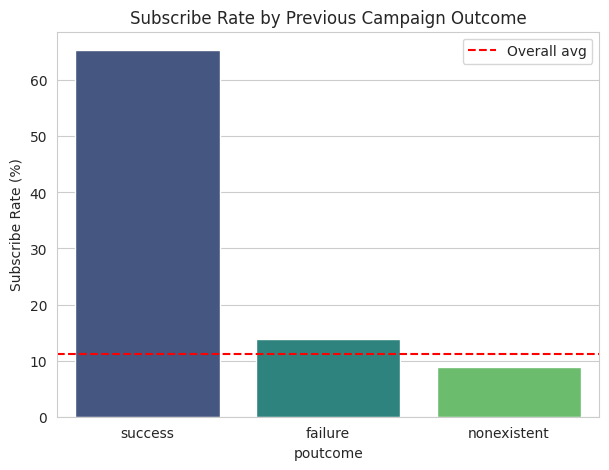

In [23]:
# Does the outcome of a PREVIOUS campaign predict success in this one?
poutcome_rate = df.groupby('poutcome')['y'].agg(
    subscribe_rate=lambda x: (x=='yes').mean()*100,
    group_size='count'
).sort_values('subscribe_rate', ascending=False)
print(poutcome_rate.round(2))

plt.figure(figsize=(7,5))
sns.barplot(x=poutcome_rate.index, y=poutcome_rate['subscribe_rate'], palette='viridis')
plt.ylabel('Subscribe Rate (%)')
plt.title('Subscribe Rate by Previous Campaign Outcome')
plt.axhline(11.27, color='red', linestyle='--', label='Overall avg')
plt.legend()
plt.show()

       subscribe_rate  group_size
month                            
mar             50.94         532
apr             20.36        2564
may              6.50       13301
jun             10.59        5081
jul              9.02        6970
aug             10.56        5987
sep             44.69         546
oct             43.98         689
nov             10.11        4017
dec             48.85         174


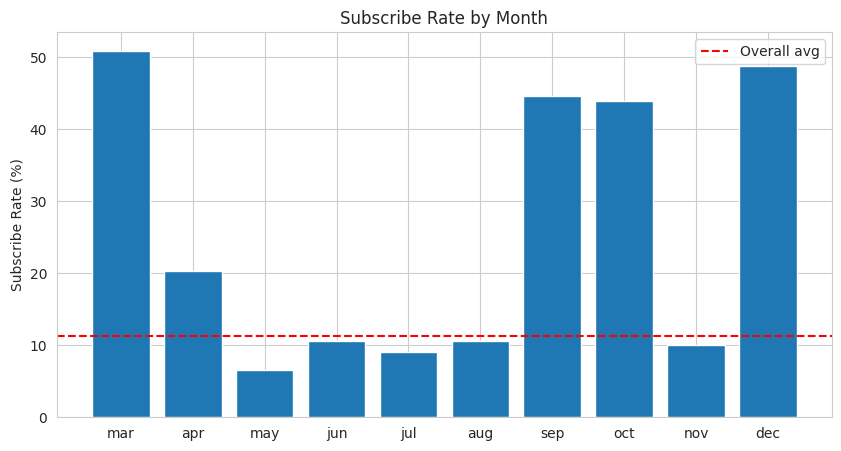

In [24]:
# Does month of contact matter? Order months chronologically, not alphabetically
month_order = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_rate = df.groupby('month')['y'].agg(
    subscribe_rate=lambda x: (x=='yes').mean()*100,
    group_size='count'
).reindex(month_order).dropna()
print(month_rate.round(2))

plt.figure(figsize=(10,5))
plt.bar(month_rate.index, month_rate['subscribe_rate'])
plt.ylabel('Subscribe Rate (%)')
plt.title('Subscribe Rate by Month')
plt.axhline(11.27, color='red', linestyle='--', label='Overall avg')
plt.legend()
plt.show()

### The `duration` trap

Recall from Section 1: `duration` is how long the call lasted, in seconds. Think
carefully -- **do you know the call duration before you make the call, or only after
it ends?** This matters a lot for how this column can honestly be used.

In [25]:
# Check: is duration related to outcome?
print(df.groupby('y')['duration'].mean())

y
no     221.192332
yes    553.537264
Name: duration, dtype: float64


**The trap, explained:** `duration` is almost perfectly informative about the
outcome -- calls that end in "yes" are typically much longer than calls that end in
"no" (a 0-second call obviously can't be a "yes"). But you only know the duration
*after* the call has already happened -- it's not something you can use to *decide*
who to call in advance. Using `duration` as a targeting feature would be circular
reasoning: it doesn't tell you who to call, it just confirms which calls went well
after the fact. This is a well-known real issue with this specific dataset --
worth explicitly excluding `duration` from any targeting recommendation or
predictive model, and explaining why if asked.

## 6. Business Recommendations

**1. Prioritize customers whose previous campaign succeeded.**
Customers with a prior campaign success subscribe at **65.4%** this time, versus
**8.9%** for those never contacted before and **13.9%** for those whose last
campaign failed -- nearly 6x the overall average of 11.3%. This is the single
strongest signal in the dataset. Recommendation: before running a new campaign,
pull the list of prior-success customers and contact them first -- they represent
the highest-return, lowest-effort segment available.

**2. Target retired (60+) and student customers as core demographic segments.**
The 60+ age band converts at **45.5%** and students (concentrated in the 18-30
band) convert at **32.9%**, both with reliable group sizes (600-700+ each) --
not statistical flukes. Combined analysis confirmed the 60+ effect holds
regardless of marital status, so it's a genuine age-driven pattern, not a proxy
for something else. Recommendation: weight campaign targeting toward these two
groups over working-age segments (31-50), which convert at roughly a third of
this rate (8-10%).

**3. Cap contact attempts at 3-4 per customer.**
Subscribe rate declines steadily with each additional contact -- from **13.0%**
on the first attempt down to **4-6%** by the 7th-10th attempt. Continuing to
call past 3-4 attempts shows diminishing, and likely negative, returns (repeated
unwanted calls may actively discourage a "yes"). Recommendation: set a hard cap
of 3-4 attempts per customer per campaign cycle, and redirect that effort toward
higher-probability segments instead.

**4. Data limitation, stated for transparency.**
`duration` (call length) is strongly associated with a successful outcome (553s
average for "yes" vs 221s for "no"), but this value is only known *after* a call
ends -- it cannot inform who to call in advance, so it was deliberately excluded
from all targeting conclusions above. Flagging this avoids a common mistake in
this specific dataset: using a feature that looks predictive but is actually
just a byproduct of the outcome itself.

**5. Scope note.**
This analysis focused on actionable segmentation rather than a predictive
model, since the goal was a clear, explainable targeting recommendation a
campaign team could act on directly -- not a black-box probability score. A
classification model (e.g. logistic regression) could be added as a next step
to rank individual customers, but the four recommendations above are usable
immediately without one.